# ELECTRICITY CONSUMPTION PREDICTIONS

# Importing the Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib


# Generate the dataset

In [17]:
np.random.seed(42)
data_size = 500

temperature = np.random.uniform(5, 45, data_size)
time_of_day = np.random.randint(0, 24, data_size)
active_appliances = np.random.randint(1, 20, data_size)
humidity = np.random.uniform(20, 90, data_size)
day_of_week = np.random.randint(1, 8, data_size)    # 1–7 (Mon–Sun)

# Non-linear consumption behavior
energy_usage = (
    0.8*temperature +
    1.4*time_of_day +
    2.2*active_appliances -
    0.3*humidity +
    3*np.sin(time_of_day/24 * 2 * np.pi) +           # peak hours pattern
    np.random.normal(0, 6, data_size)
)

df = pd.DataFrame({
    "Temperature": temperature,
    "Humidity": humidity,
    "TimeOfDay": time_of_day,
    "DayOfWeek": day_of_week,
    "ActiveAppliances": active_appliances,
    "EnergyUsage_kWh": energy_usage
})

df.head()


,Temperature,Humidity,TimeOfDay,DayOfWeek,ActiveAppliances,EnergyUsage_kWh
0,19.981605,59.088887,21,5,2,31.373148
1,43.028572,35.787810,16,5,17,89.464384
2,34.279758,31.257783,8,4,11,48.017307
3,28.946339,65.606363,0,1,12,33.184518
4,11.240746,42.814782,20,3,19,61.930232


# Checking correlation

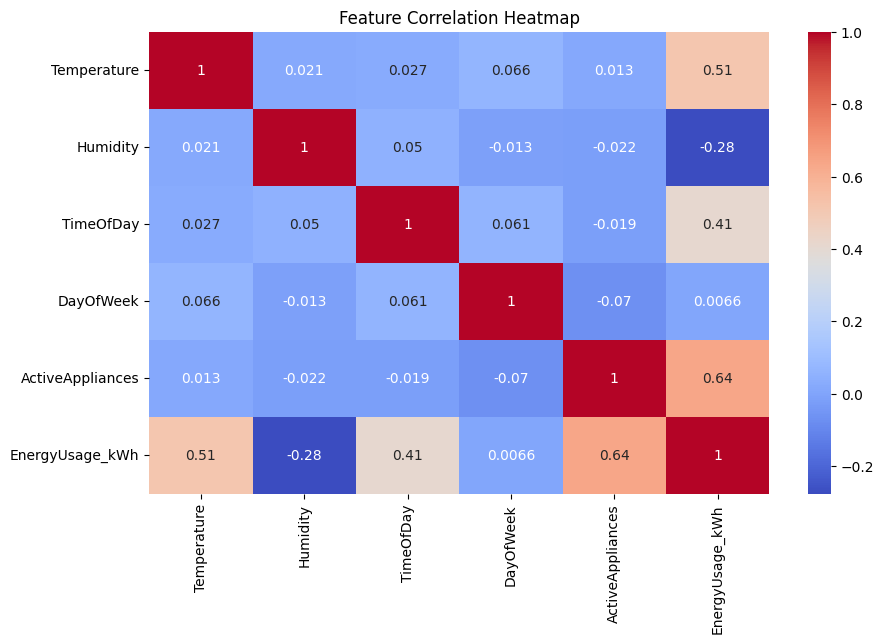

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


# Split Train / Validation / Test

In [19]:
X = df.drop("EnergyUsage_kWh", axis=1)
y = df["EnergyUsage_kWh"]

# first: train + temp_test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42)

# second: validation + final_test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)


# Feature scaling

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


# MODEL 1: Linear Regression

In [24]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_val_scaled)

print("Linear Regression MAE:", mean_absolute_error(y_val, lr_pred))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_val, lr_pred)))


Linear Regression MAE: 4.849782383656123
Linear Regression RMSE: 6.131914472076001


# MODEL 2: Random Forest (with hyperparameter tuning)

In [25]:
rf = RandomForestRegressor()

params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(rf, params, cv=3, scoring="neg_mean_squared_error", n_jobs=-1)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

rf_pred = best_rf.predict(X_val)

print("Random Forest MAE:", mean_absolute_error(y_val, rf_pred))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_val, rf_pred)))
print("Best Hyperparameters:", grid.best_params_)


Random Forest MAE: 6.341600497081673
Random Forest RMSE: 8.297948745081504
Best Hyperparameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


# Pick the best model

In [26]:
best_model = lr if mean_absolute_error(y_val, lr_pred) < mean_absolute_error(y_val, rf_pred) else best_rf
print("Selected Model:", best_model)


Selected Model: LinearRegression()


# Final evaluation on Test Set

In [27]:
if best_model == lr:
    final_pred = best_model.predict(X_test_scaled)
else:
    final_pred = best_model.predict(X_test)

print("Final MAE:", mean_absolute_error(y_test, final_pred))
print("Final RMSE:", np.sqrt(mean_squared_error(y_test, final_pred)))


Final MAE: 4.662083821959242
Final RMSE: 5.781651999944478


# Save the best model


In [28]:
joblib.dump(best_model, "energy_model.pkl")
joblib.dump(scaler, "feature_scaler.pkl")

print("Model and scaler saved successfully!")


Model and scaler saved successfully!


# Load and Test Model with Custom Input

In [29]:
# Load model
model = joblib.load("energy_model.pkl")
scaler = joblib.load("feature_scaler.pkl")

# Example input:
example = pd.DataFrame({
    "Temperature": [32],
    "Humidity": [55],
    "TimeOfDay": [18],
    "DayOfWeek": [4],
    "ActiveAppliances": [8]
})

# scale features (if LR)
if isinstance(model, LinearRegression):
    example_scaled = scaler.transform(example)
    result = model.predict(example_scaled)
else:
    result = model.predict(example)

print("Predicted Energy Usage (kWh):", result[0])


Predicted Energy Usage (kWh): 50.21712910844981
